### Exercise 5

#### AI declaration
For this exercise Gemini was used to answer the question

In [5]:
#importing statements
import numpy as np
import matplotlib.pyplot as plt

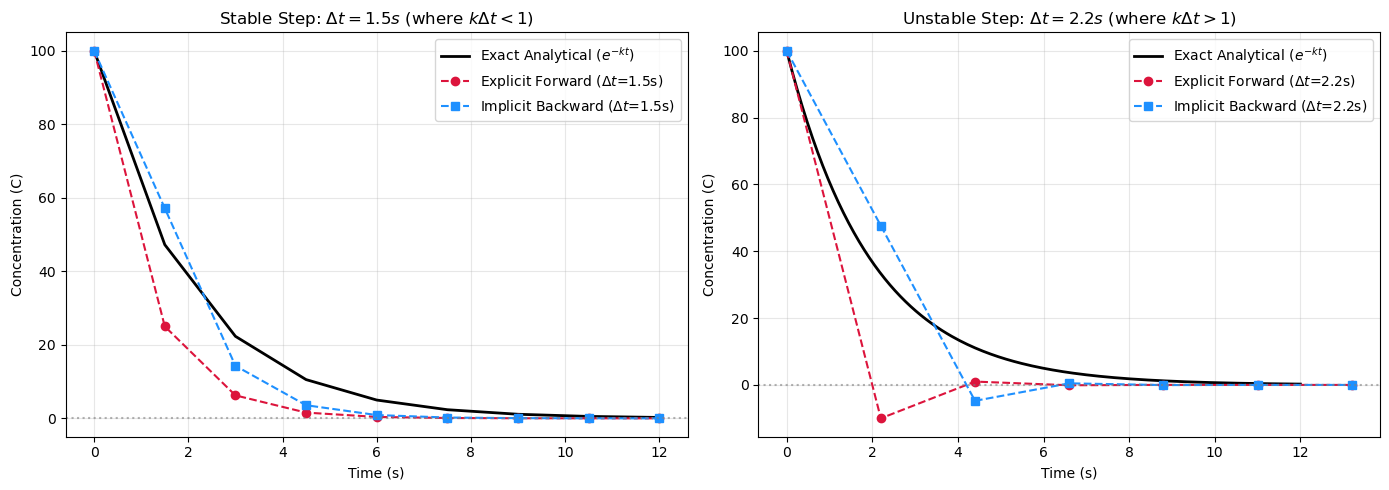

In [6]:
#plotting graphs to show condition that are stable and unstable
def simulate_decay(C0, k, dt, T_max):
    """
    Simulates physical decay using Explicit Forward Euler and Implicit Backward Euler.
    """
    # Time arrays
    time_steps = np.arange(0, T_max + dt, dt)
    n_steps = len(time_steps)
    
    # Initialize solution arrays
    C_explicit = np.zeros(n_steps)
    C_implicit = np.zeros(n_steps)
    C_exact = np.zeros(n_steps)
    
    # Set initial conditions
    C_explicit[0] = C0
    C_implicit[0] = C0
    C_exact[0] = C0
    
    # Time-stepping loop
    for n in range(0, n_steps - 1):
        # 1. Explicit Euler Forward: C^(n+1) = (1 - k*dt) * C^n
        C_explicit[n+1] = (1 - k * dt) * C_explicit[n]
        
        # 2. Implicit Euler Backward: C^(n+1) = C^n / (1 + k*dt)
        C_implicit[n+1] = C_explicit[n] / (1 + k * dt)
        
        # Exact analytical solution for comparison: C(t) = C0 * e^(-kt)
        C_exact[n+1] = C0 * np.exp(-k * time_steps[n+1])
        
    return time_steps, C_explicit, C_implicit, C_exact

# --- Simulation Parameters ---
C0 = 100.0   # Initial concentration
k = 0.5      # Decay constant (1/s)
T_max = 12.0 # Total simulation time (seconds)

# Critical time step threshold for explicit stability is 1/k
dt_stable = 1.5    # dt < 1/k (0.5 * 1.5 = 0.75, which is < 1) -> Stable
dt_unstable = 2.2  # dt > 1/k (0.5 * 2.2 = 1.1, which is > 1) -> Unstable

# --- Run Simulations ---
t_stable, exp_stable, imp_stable, exact_stable = simulate_decay(C0, k, dt_stable, T_max)
t_unstable, exp_unstable, imp_unstable, exact_unstable = simulate_decay(C0, k, dt_unstable, T_max)

# --- Plotting the Results ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Stable Case
ax1.plot(t_stable, exact_stable, 'k-', label='Exact Analytical ($e^{-kt}$)', linewidth=2)
ax1.plot(t_stable, exp_stable, 'o--', color='crimson', label=f'Explicit Forward ($\Delta t$={dt_stable}s)')
ax1.plot(t_stable, imp_stable, 's--', color='dodgerblue', label=f'Implicit Backward ($\Delta t$={dt_stable}s)')
ax1.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax1.set_title(f'Stable Step: $\Delta t = {dt_stable}s$ (where $k\Delta t < 1$)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Concentration (C)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Unstable Case
# Generating a smoother exact curve for the unstable plot background
t_fine = np.linspace(0, T_max, 200)
exact_fine = C0 * np.exp(-k * t_fine)

ax2.plot(t_fine, exact_fine, 'k-', label='Exact Analytical ($e^{-kt}$)', linewidth=2)
ax2.plot(t_unstable, exp_unstable, 'o--', color='crimson', label=f'Explicit Forward ($\Delta t$={dt_unstable}s)')
ax2.plot(t_unstable, imp_unstable, 's--', color='dodgerblue', label=f'Implicit Backward ($\Delta t$={dt_unstable}s)')
ax2.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax2.set_title(f'Unstable Step: $\Delta t = {dt_unstable}s$ (where $k\Delta t > 1$)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Concentration (C)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
def print_formal_stability_proof(k, dt):
    """
    Prints a beautifully formatted, structured step-by-step physical stability proof
    for the Implicit Euler Backward scheme using clear text-based math layout.
    """
    # Numerical calculations for the example run
    k_dt = k * dt
    denominator = 1 + k_dt
    multiplier = 1 / denominator
    
    # Text-formatting assets
    double_line = "=" * 78
    single_line = "-" * 78
    
    print(double_line)
    print("  MATHEMATICAL PROOF: UNCONDITIONAL STABILITY OF IMPLICIT EULER BACKWARD")
    print(double_line)
    
    # Context & Parameters
    print(f"Given System Variables:")
    print(f"  • Physical Decay Rate (k) = {k} (> 0)")
    print(f"  • Selected Time Step (Δt) = {dt} (> 0)")
    print(single_line)
    
    # STEP 1
    print("STEP 1: ISOLATE THE AMPLIFICATION MULTIPLIER")
    print("  The discrete implicit backward formulation is defined as:")
    print("                Cⁿ")
    print("    Cⁿ⁺¹  =  ───────────")
    print("             1 + k * Δt")
    print("\n  Factoring out the current state (Cⁿ) isolates the multiplier matrix/factor:")
    print("               ┌     1     ┐")
    print("    Cⁿ⁺¹  =    │ ───────── │  * Cⁿ")
    print("               └ 1 + k * Δt┘")
    print(f"\n  [Numerical Example]:  1 / (1 + {k} * {dt})  =  1 / {denominator:.4f}  =  {multiplier:.4f}")
    print(single_line)
    
    # STEP 2
    print("STEP 2: ESTABLISH PHYSICAL STABILITY BOUNDS")
    print("  To match physical reality and remain stable, any concentration factor (A)")
    print("  evolving forward in time must obey two bounded constraints:")
    print("    1. Positivity:  A  ≥  0   (Prevents impossible negative concentrations)")
    print("    2. Decay:       A  ≤  1   (Prevents unphysical numerical amplification)")
    print("\n  Therefore, the stable bounding envelope is strictly:")
    print("              0  ≤   A   ≤  1")
    print(single_line)
    
    # STEP 3
    print("STEP 3: ANALYZE THE DENOMINATOR ALGEBRAICALLY")
    print("  We examine the physical parameters governing the system denominator:")
    print("    • The time step step size is fundamentally positive:  Δt > 0")
    print("    • The physical decay coefficient is positive:         k  > 0")
    print("\n  Consequently, their combined product must always scale greater than zero:")
    print(f"    k * Δt  >  0      (Physically: {k} * {dt} = {k_dt:.4f} > 0)")
    print("\n  Adding 1 to this positive product guarantees a denominator strictly greater than 1:")
    print(f"    1 + k * Δt  >  1  (Physically: 1 + {k_dt:.4f} = {denominator:.4f} > 1)")
    print(single_line)
    
    # STEP 4
    print("STEP 4: EVALUATE SYSTEM STABILITY CRITERIA")
    print("  Let us test the algebraic properties of our structural fraction:")
    print("               1 ")
    print("         ───────────")
    print("         1 + k * Δt")
    
    # Positivity Test
    print("\n  [TEST A]: Positivity Verification (Numerator > 0  and  Denominator > 1)")
    print(f"    Since both terms are strictly positive, the quotient cannot cross below 0.")
    print(f"    Result:  {multiplier:.4f}  ≥  0  ──>  [PASSED: Solution remains positive]")
    
    # Decay Test
    print("\n  [TEST B]: Bounded Decay Verification (Denominator > Numerator)")
    print(f"    Since the denominator is always greater than 1, the total fraction value")
    print(f"    is forced to remain smaller than 1.")
    print(f"    Result:  {multiplier:.4f}  ≤  1  ──>  [PASSED: Concentration naturally attenuates]")
    print(single_line)
    
    # STEP 5
    print("STEP 5: FINAL STABILITY CONCLUSION")
    print("  Because the system parameters hold true for any positive framework:")
    print("                     ┌     1     ┐")
    print("         0   <       │ ───────── │       <   1")
    print("                     └ 1 + k * Δt┘")
    print("\n  This stability rule contains absolutely no upper limits or constraints on Δt.")
    print("  You can increase Δt infinitely, and the scheme will safely step forward without")
    print("  diverging or oscillating.")
    print("\n  CONCLUSION: THE IMPLICIT EULER BACKWARD SCHEME IS UNCONDITIONALLY STABLE.")
    print(double_line)

# --- Execute script ---
print_formal_stability_proof(k=0.5, dt=2.2)

  MATHEMATICAL PROOF: UNCONDITIONAL STABILITY OF IMPLICIT EULER BACKWARD
Given System Variables:
  • Physical Decay Rate (k) = 0.5 (> 0)
  • Selected Time Step (Δt) = 2.2 (> 0)
------------------------------------------------------------------------------
STEP 1: ISOLATE THE AMPLIFICATION MULTIPLIER
  The discrete implicit backward formulation is defined as:
                Cⁿ
    Cⁿ⁺¹  =  ───────────
             1 + k * Δt

  Factoring out the current state (Cⁿ) isolates the multiplier matrix/factor:
               ┌     1     ┐
    Cⁿ⁺¹  =    │ ───────── │  * Cⁿ
               └ 1 + k * Δt┘

  [Numerical Example]:  1 / (1 + 0.5 * 2.2)  =  1 / 2.1000  =  0.4762
------------------------------------------------------------------------------
STEP 2: ESTABLISH PHYSICAL STABILITY BOUNDS
  To match physical reality and remain stable, any concentration factor (A)
  evolving forward in time must obey two bounded constraints:
    1. Positivity:  A  ≥  0   (Prevents impossible negative concent